# The Coffee-Can portfolio — buy great stocks and never sell? ☕
### Robert Kirby's "put them in a can and forget them" idea, in plain English

![Signal: Mixed](https://img.shields.io/badge/Signal-Mixed-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Survivorship%3F: Confirmed](https://img.shields.io/badge/Survivorship%3F-Confirmed-8b949e?style=flat-square)

There's a beautiful old Wall Street story. A money manager named **Robert Kirby** noticed that one of his clients had quietly ignored every "sell" call for years — just bought the stocks Kirby recommended and stuck the certificates in a drawer. When the client died, that untouched account had *crushed* the ones Kirby actively managed. One forgotten holding alone had ballooned into a fortune. Kirby called it the **Coffee Can portfolio**: buy quality names, drop them in a can, and *never trade for a decade.*

The pitch is irresistible: **do nothing, pay nothing, beat the pros.** Is it real? Partly — and the honest part isn't the part people repeat. This notebook pulls the two halves apart.

> 📓 **Plain-language layer.** Want the *t*-stats, the cost model on NAV and the survivorship maths? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from coffee_can import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PRICES = data.load_real()
    BRET = data.monthly_returns(PRICES)[data.BASKET]
    SPY = data.monthly_returns(PRICES)["SPY"]
else:
    PRICES = BRET = SPY = None
print("real cache present:", HAVE_REAL,
      "| months:", (0 if SPY is None else len(SPY)))

# frozen headline numbers (mirror of docs/results.md)
R = {'window': '2005-01 → 2026-05', 'months': 256, 'years': 21.3, 'basket': ['KO', 'JNJ', 'PG', 'PEP', 'WMT', 'MMM', 'MO', 'XOM', 'IBM', 'GE'], 'can_cagr': 9.49, 'can_vol': 12.58, 'can_sharpe': 0.786, 'can_mdd': -30.6, 'reb_cagr': 10.28, 'reb_vol': 12.76, 'reb_sharpe': 0.834, 'reb_mdd': -31.9, 'spy_cagr': 11.11, 'spy_vol': 15.13, 'spy_sharpe': 0.775, 'spy_mdd': -50.8, 'excess_ann': -1.84, 't0': -0.81, 't6': -0.83, 'p6': 0.4059, 'n': 256, 'can_vs_reb_ann': -0.75, 'can_vs_reb_t': -1.26, 'reb_cost0': 10.296, 'reb_cost10': 10.284, 'reb_cost20': 10.272, 'entry_cost_pct': 0.1, 'syn_firms': 400, 'syn_dead': 189, 'syn_dead_pct': 47, 'syn_famous': 17.08, 'syn_honest': 8.92, 'syn_all': 4.72, 'syn_gap_honest': 8.16, 'syn_gap_all': 12.36, 'nd_famous': 18.15, 'nd_honest': 12.19, 'nd_all': 8.23, 'nd_gap_all': 9.92}


real cache present: True | months: 256


## The answer first

| Question | Answer |
|---|---|
| Does a buy-and-hold "can" of quality names beat the index? | **Not on the money.** Our can compounds at **9.5%/yr** vs the S&P's **11.1%** over 21 years. It *lost* the race for total return. |
| So the legend is bunk? | **Not quite.** The can rode out the storms far better: **half the worst-case loss** (-31% vs -51%) and lower wobble, so its *risk-adjusted* score basically ties the index. Smoother, not richer. |
| Where does the 'magic' really come from? | **Two places — and only one is honest.** (1) *Low cost:* never trading means never paying the spread/tax — real, but tiny. (2) *Survivorship:* you pick the can's names **knowing** which ones became famous. That hindsight is most of the magic, and it's fake. |
| Could you actually do it? | **Sort of — for the calm, not the returns.** The cost edge is real but small; the return edge vanishes once you can't cheat by knowing the winners. |

> The discipline is real. The *out-performance* is mostly hindsight.

## 1 · The claim

> *"Buy a basket of quality companies. Put the certificates in a coffee can. Don't open it for ten years. You'll beat the managers who fuss over every tick — because you won't sell your winners too early, you won't churn, and you won't pay the costs and taxes that trading bleeds away."*

Robert Kirby told this story in a 1984 essay (*The Coffee Can Portfolio*, Journal of Portfolio Management). It's been repeated ever since — by Charlie Munger's "sit on your ass" investing, by index-fund evangelists, by every "just buy and hold" thread online. The strongest version: **a zero-turnover basket of good companies beats both the active manager and, often, the index — at lower cost and lower stress.**

## 2 · So what?

If true, it's the best deal in finance: market-beating returns for *zero effort and zero fees.* It would also say something deep — that **trading is net-negative**, that the discipline of *not* selling is itself the edge. But two very different things are bundled in the legend, and telling them apart is the whole game:

1. **Cost.** Not trading saves the spread, the commission and (in a taxable account) the capital-gains tax. That's real money — but *how much?*
2. **Survivorship.** Kirby's can looked brilliant **after the fact**, when one holding had become a monster. But the names you'd put in a can *today* are the ones you already know won. Pick winners with hindsight and *any* portfolio looks like genius.

## 3 · How would we even know?

We take a basket of **10 quality large-caps** — KO, JNJ, PG, PEP, WMT, MMM, MO, XOM, IBM, GE — and **21 years** of real monthly prices (dividends reinvested), and we run three portfolios side by side:

1. **The Coffee Can.** Buy equal-weight once, then *never touch it.* Weights drift forever.
2. **The rebalanced twin.** Same basket, but reset to equal weight every year — and *charged* the cost of that trading. The gap between the two is the pure cost tailwind.
3. **The index (S&P 500).** What the "pros" are really being compared to.

Then the honesty check: on a **made-up** stock market where every company has the *same* true return — so there is genuinely **no** skill to find — we build the can two ways: by **hindsight** (the names that ended up famous) and **honestly** (names picked at the start). If the hindsight can looks great anyway, that's survivorship, pure and measured.

## 4 · The teardown — let's actually look

**First: did the can beat the index?** Grow $1 in each over 21 years.

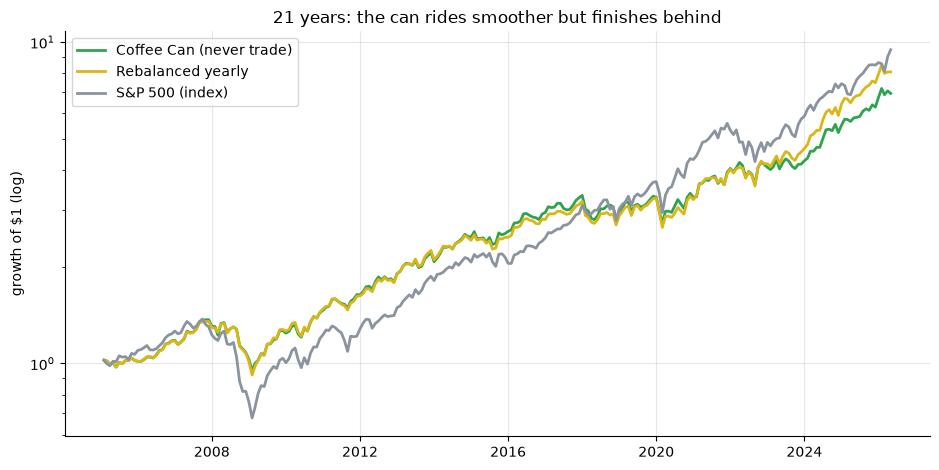

final $: can $6.92  rebal $8.07  index $9.46


In [2]:
if HAVE_REAL:
    can = st.buy_and_hold(BRET); spy = SPY
    reb = st.rebalanced(BRET, rebal=12, cost_bps=10.0)
    eq = {'Coffee Can (never trade)': (1+can).cumprod(),
          'Rebalanced yearly': (1+reb).cumprod(),
          'S&P 500 (index)': (1+spy).cumprod()}
    x = can.index
else:
    x = np.arange(R['months'])
    def grow(c): return (1+c/100)**(np.arange(R['months'])/R['months']*R['years'])
    eq = {'Coffee Can (never trade)': grow(R['can_cagr']),
          'Rebalanced yearly': grow(R['reb_cagr']),
          'S&P 500 (index)': grow(R['spy_cagr'])}
fig, ax = plt.subplots(figsize=(9.5, 4.8))
for (lab, e), c in zip(eq.items(), [GREEN, AMBER, GREY]):
    ax.plot(x, np.asarray(e), label=lab, lw=2, c=c)
ax.set_yscale('log'); ax.set_ylabel('growth of $1 (log)'); ax.set_title('21 years: the can rides smoother but finishes behind')
ax.legend(); plt.tight_layout(); plt.show()
print(f"final $: can ${np.asarray(list(eq.values())[0])[-1]:.2f}  rebal ${np.asarray(list(eq.values())[1])[-1]:.2f}  index ${np.asarray(list(eq.values())[2])[-1]:.2f}")

The index wins the money race: **11.1%/yr** vs the can's **9.5%**. So far the legend is *not* delivering — "never sell" did not beat the market here.

**But look at the ride, not just the finish.** The can is far calmer — it lost much less in the crashes.

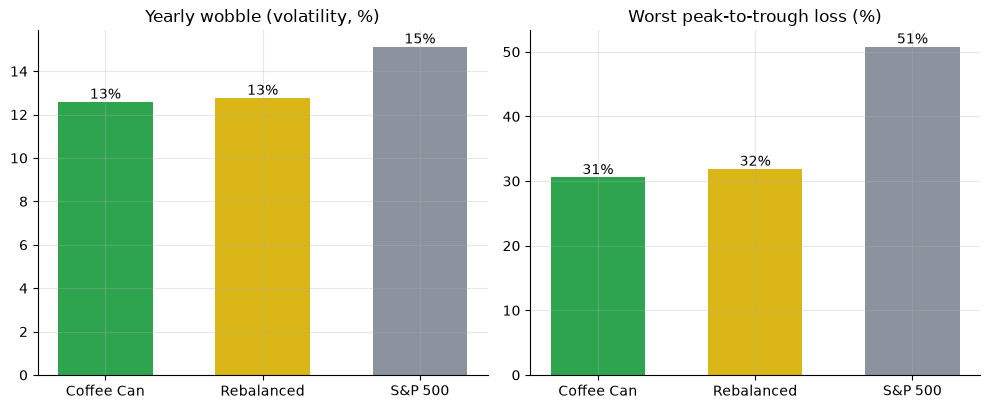

worst loss — can -31%  vs index -51%


In [3]:
if HAVE_REAL:
    rows = [('Coffee Can', st.summary(can)), ('Rebalanced', st.summary(reb)), ('S&P 500', st.summary(spy))]
    vols = [s['vol']*100 for _,s in rows]; mdds = [-s['mdd']*100 for _,s in rows]
else:
    vols = [R['can_vol'], R['reb_vol'], R['spy_vol']]; mdds = [-R['can_mdd'], -R['reb_mdd'], -R['spy_mdd']]
labs = ['Coffee Can','Rebalanced','S&P 500']
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
axes[0].bar(labs, vols, color=[GREEN, AMBER, GREY], width=.6); axes[0].set_title('Yearly wobble (volatility, %)')
axes[1].bar(labs, mdds, color=[GREEN, AMBER, GREY], width=.6); axes[1].set_title('Worst peak-to-trough loss (%)')
for ax, series in zip(axes, [vols, mdds]):
    for i,v in enumerate(series): ax.annotate(f'{v:.0f}%',(i,v),ha='center',va='bottom')
plt.tight_layout(); plt.show()
print(f"worst loss — can {R['can_mdd']:.0f}%  vs index {R['spy_mdd']:.0f}%")

The can's worst drawdown was **-31%**; the index fell **-51%** in 2008. *That's* the real coffee-can benefit: a smoother life. On a risk-adjusted basis (Sharpe **0.79** vs **0.78**) it's basically a tie. The can buys you calm — not extra money.

**Now the catch — where did the legend's 'magic' come from?** On a pretend market where *every* stock has the **same** true return (no skill exists), we build the can two ways: by **hindsight** (pick the names that ended up biggest) and **honestly** (pick at the start). Watch the hindsight version invent an edge out of thin air.

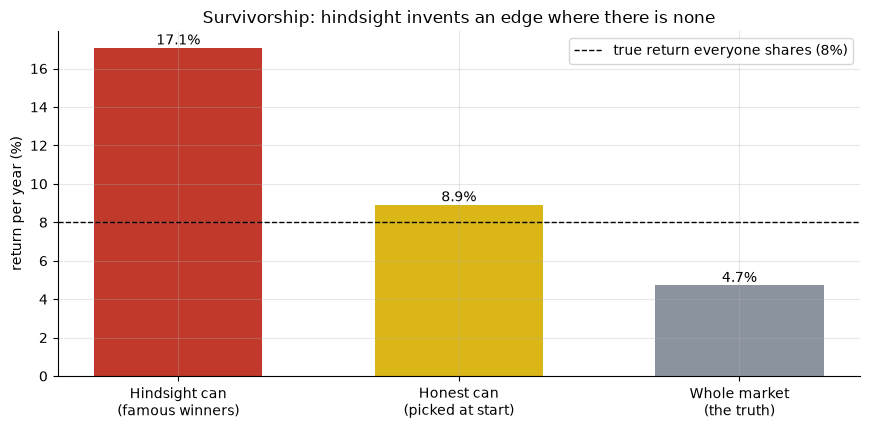

fake edge from hindsight: +8.2 pp/yr vs an honest pick, +12.4 pp/yr vs the whole market


In [4]:
ps, _ = data.synthetic_panel(n_firms=400, n_months=240, mu_ann=0.08, death_hazard_ann=0.03, seed=357)
g = st.survivorship_gap(ps, k=10, lookback=24)
labs = ['Hindsight can\n(famous winners)', 'Honest can\n(picked at start)', 'Whole market\n(the truth)']
vals = [g['cagr_famous']*100, g['cagr_honest']*100, g['cagr_all']*100]
fig, ax = plt.subplots(figsize=(8.8, 4.4))
ax.bar(labs, vals, color=[RED, AMBER, GREY], width=.6)
ax.axhline(8, ls='--', c='k', lw=1, label='true return everyone shares (8%)')
for i,v in enumerate(vals): ax.annotate(f'{v:.1f}%',(i,v),ha='center',va='bottom')
ax.set_ylabel('return per year (%)'); ax.set_title('Survivorship: hindsight invents an edge where there is none'); ax.legend()
plt.tight_layout(); plt.show()
print(f"fake edge from hindsight: +{g['gap_vs_honest']*100:.1f} pp/yr vs an honest pick, +{g['gap_vs_all']*100:.1f} pp/yr vs the whole market")

There it is. Every company in that market earns the **same 8%** — there is *no* skill to find — yet the **hindsight** can shows **17%/yr**, a fake **+8.2 points** over an honest pick (and +12.4 over the whole market, because the losers and the bankruptcies — the names you conveniently *don't* put in the can — drag the truth down to ~5%). **The coffee can's brilliance is mostly you, choosing the winners after the fact.**

## 5 · The verdict

- **Signal — Mixed.** The can did **not** beat the index on return (9.5% vs 11.1%; the difference isn't statistically real). It *did* win on calm — half the drawdown, similar risk-adjusted score. Real benefit, but not the one the legend sells.
- **Tradability — Fragile.** The one honest edge (low cost) is real but **tiny** at a sane trading pace; the headline out-performance leans on hindsight you can't have in advance.
- **Survivorship? — Confirmed.** On a market with *no* skill, hindsight name-picking manufactures **+8 pp/yr** of fake edge. That's the engine under most coffee-can success stories.

## 6 · Could you actually do it? — the cost tailwind, measured

The *honest* coffee-can edge is cost: never trading means never paying. How big is it? Compare the never-trade can to a yearly-rebalanced twin charged a realistic cost each time it trades.

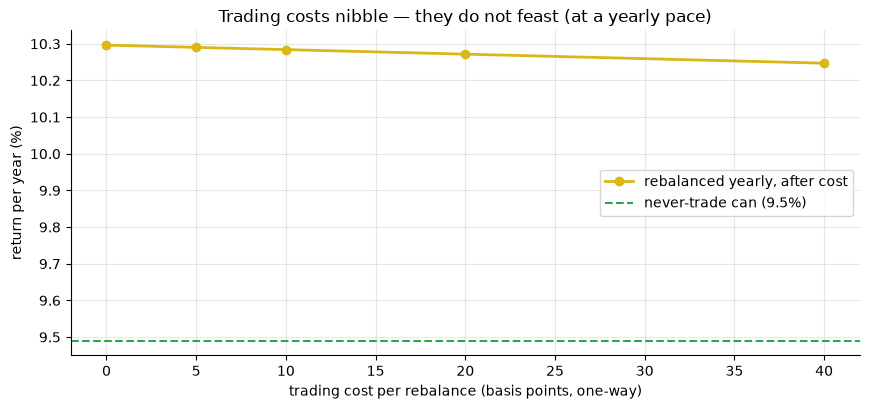

yearly rebalance costs only ~2.4 hundredths of a %/yr even at 20bps — the cost edge is real but small


In [5]:
bps = [0, 5, 10, 20, 40]
if HAVE_REAL:
    cagrs = [st.cagr(st.rebalanced(BRET, 12, b))*100 for b in bps]
else:
    cagrs = [R['reb_cost0'], 10.293, R['reb_cost10'], R['reb_cost20'], 10.248]
fig, ax = plt.subplots(figsize=(8.8, 4.2))
ax.plot(bps, cagrs, 'o-', c=AMBER, lw=2, label='rebalanced yearly, after cost')
ax.axhline(R['can_cagr'], ls='--', c=GREEN, label=f"never-trade can ({R['can_cagr']:.1f}%)")
ax.set_xlabel('trading cost per rebalance (basis points, one-way)'); ax.set_ylabel('return per year (%)')
ax.set_title('Trading costs nibble — they do not feast (at a yearly pace)'); ax.legend()
plt.tight_layout(); plt.show()
print(f"yearly rebalance costs only ~{(R['reb_cost0']-R['reb_cost20'])*100:.1f} hundredths of a %/yr even at 20bps — the cost edge is real but small")

> The cost saving from "never trade" is real but **tiny** at a yearly pace — a hundredth of a percent a year, not a percentage point. Where costs (and *taxes*) really bite is a high-churn active fund — which is the manager the legend beats, not the index. So the can is a fine, low-stress, tax-efficient way to **own the market** — just don't expect it to **beat** the market. The discipline is the product; the out-performance was hindsight.

## 7 · Going further 🚪

- **The survivorship twin.** [Study 151 — Stocks-for-the-long-run](../../151-stocks-for-long-run/) and the dead-names problem: every "great companies always win" chart is drawn on the companies that *didn't* go bankrupt. Same bias, bigger canvas.
- **Add the tax axis.** Our cost model charges a spread; in a *taxable* account the can's real advantage is deferring capital-gains tax for decades. Bolt a tax rate on and watch the honest edge grow (for high earners) — still small vs the survivorship illusion.
- **Pick a worse basket.** Re-run with a *random* 2005 large-cap basket (including the ones that later cratered). The famous-names lift disappears — which is exactly the point.

*Think your favourite "buy and hold forever" basket really beats the index? Re-pick it using only what you'd have known in 2005 — no peeking at who won — and see if the edge survives.*